# First-Visit Monte Carlo Control for Blackjack-v1

In [1]:
# DONE: Imports and setup
import sys
sys.path.insert(0, "../src")

import gymnasium as gym
import numpy as np

## Acceptance Tests

In [2]:
# TODO: Acceptance test - Agent performance (bake-off)
# - Run NaiveAgent (random, always_hit, always_stick), BasicStrategy, and
#   trained BlackjackAgent each for 10,000 episodes
# - Trained agent's average return should exceed all naive baselines
# - Trained agent's average return should approach or exceed BasicStrategy

In [3]:
# TODO: Acceptance test - Visualizations render correctly
# - 3D surface plots (value function) for usable and non-usable ace
# - Learning curves with smoothing show improving average returns
# - Bake-off comparison chart showing average returns across all agents

In [4]:
# TODO: Acceptance test - CLI simulation
# - BlackjackSimulation can be invoked from the command line
# - Accepts parameters for num_episodes, epsilon, decay schedule
# - Produces saved plot artifacts

## BlackjackAgent

In [5]:
# DONE: BlackjackAgent - stub
# - __init__(epsilon, discount_factor): initialize Q-values, returns_sum,
#   returns_count, and epsilon-soft policy
# - select_action(state): return action using epsilon-soft policy
# - update(episode): first-visit MC update from a complete episode trajectory
#   - Work backward through episode to compute returns
#   - Update Q-values only for first visits to each (state, action) pair
# - get_policy(): return greedy policy derived from Q-values
# - get_value_function(): return state-value function (max Q over actions)

In [6]:
# DONE: BlackjackAgent - unit tests
# See src/test_blackjack_agent.py for full test suite
!cd ../src && python -m pytest test_blackjack_agent.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 15 items                                                             

test_blackjack_agent.py::TestBlackjackAgentStub::test_constructor_sets_epsilon PASSED [  6%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_constructor_sets_discount_factor PASSED [ 13%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_select_action_returns_valid_action PASSED [ 20%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_select_action_returns_int PASSED [ 26%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_update_accepts_episode PASSED [ 33%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_get_policy_returns_dict PASSED [ 40%]
test_blackjack_agent.py::TestBlackjackAgentStub:

In [7]:
# DONE: BlackjackAgent - demo
from blackjack_agent import BlackjackAgent

agent = BlackjackAgent(epsilon=0.1, discount_factor=1.0)
state = (18, 6, False)
action = agent.select_action(state)
print(f"State: {state} -> Action: {'Hit' if action == 1 else 'Stick'}")
print(f"Policy: {agent.get_policy()}")
print(f"Value function: {agent.get_value_function()}")

State: (18, 6, False) -> Action: Stick
Policy: {(18, 6, False): 0}
Value function: {(18, 6, False): 0.0}


In [8]:
# DONE: BlackjackAgent - epsilon decay
# - decay_epsilon() calls injected decay_schedule callable
# - Supports any callable: lambdas for linear/exponential,
#   callable objects with internal state for cosine
# - Default is no decay (backward compatible)

## EpisodeRunner

In [9]:
# DONE: EpisodeRunner - stub
# - __init__(env): wrap a Gymnasium Blackjack-v1 environment
# - run_episode(agent): generate one complete episode trajectory
#   - env.reset() to start, collect (state, action, reward) tuples via env.step()
#   - Continue until terminated flag is True
#   - Return trajectory as a list of (state, action, reward)
# - run_training(agent, num_episodes): run multiple episodes, update agent after each
#   - Track per-episode rewards for learning curves
#   - Return list of episode rewards

In [10]:
# DONE: EpisodeRunner - demo (verbose)
from episode_runner import EpisodeRunner

env = gym.make("Blackjack-v1", sab=True)
runner = EpisodeRunner(env)
episode = runner.run_episode(agent, verbose=True)

Step 1: State=(sum=16, dealer=7, ace=False) Action=Stick Reward=1.0
Episode finished: 1 steps, Result=Win


In [11]:
# DONE: EpisodeRunner - unit tests
# See src/test_episode_runner.py for full test suite
!cd ../src && python -m pytest test_episode_runner.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 15 items                                                             

test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_returns_list PASSED [  6%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_returns_nonempty PASSED [ 13%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_tuple_structure PASSED [ 20%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_training_returns_rewards_list PASSED [ 26%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_training_rewards_are_numeric PASSED [ 33%]
test_episode_runner.py::TestEpisodeRunnerVerbose::test_verbose_false_produces_no_output PASSED [ 40%]
test_episode_runner.py::TestEpisodeRunner

In [12]:
# DONE: Integration - Agent + Runner
# See src/test_integration_cycle1.py for full test suite
!cd ../src && python -m pytest test_integration_cycle1.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 4 items                                                              

test_integration_cycle1.py::TestAgentRunnerIntegration::test_episode_feeds_into_agent_update PASSED [ 25%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_training_loop_updates_agent PASSED [ 50%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_training_loop_collects_rewards PASSED [ 75%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_agent_actions_are_valid_throughout_episode PASSED [100%]

============================== 4 passed in 0.11s ===============================


## BasicStrategy

In [13]:
# DONE: BasicStrategy - stub
# - __init__(): encode standard Blackjack basic strategy lookup tables
#   - Separate tables for hard totals and soft totals (usable ace)
# - get_action(state): return the basic strategy action for a given state
# - select_action(state): EpisodeRunner-compatible alias for get_action
# - update(episode): no-op for EpisodeRunner compatibility

In [14]:
# DONE: BasicStrategy - demo
from basic_strategy import BasicStrategy

strategy = BasicStrategy()
test_states = [(20, 6, False), (12, 2, False), (18, 9, True), (16, 10, False)]
for s in test_states:
    action = strategy.get_action(s)
    print(f"State={s} -> {'Hit' if action == 1 else 'Stick'}")

State=(20, 6, False) -> Stick
State=(12, 2, False) -> Hit
State=(18, 9, True) -> Hit
State=(16, 10, False) -> Hit


In [15]:
# DONE: BasicStrategy - unit tests + integration
# See src/test_basic_strategy.py for full test suite
!cd ../src && python -m pytest test_basic_strategy.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 16 items                                                             

test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_20 PASSED [  6%]
test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_19 PASSED [ 12%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_8 PASSED   [ 18%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_5 PASSED   [ 25%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_12_vs_dealer_2 PASSED [ 31%]
test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_12_vs_dealer_4 PASSED [ 37%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_16_vs_dealer_10 PASSED [ 43%]
test_basic_strategy.py::

## NaiveAgent

In [16]:
# DONE: NaiveAgent - stub
# - Implements select_action(state) and no-op update(episode)
#   to be compatible with EpisodeRunner
# - Three strategies: random, always_hit, always_stick
# - Serves as the performance floor in the bake-off

In [17]:
# DONE: NaiveAgent - demo
from naive_agent import NaiveAgent

for strat in ("random", "always_hit", "always_stick"):
    naive = NaiveAgent(strategy=strat)
    state = (16, 10, False)
    action = naive.select_action(state)
    print(f"Strategy={strat}: State={state} -> {'Hit' if action == 1 else 'Stick'}")

Strategy=random: State=(16, 10, False) -> Hit
Strategy=always_hit: State=(16, 10, False) -> Hit
Strategy=always_stick: State=(16, 10, False) -> Stick


In [18]:
# DONE: NaiveAgent - unit tests + integration
# See src/test_naive_agent.py for full test suite
!cd ../src && python -m pytest test_naive_agent.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 7 items                                                              

test_naive_agent.py::TestNaiveAgentActions::test_random_returns_valid_action PASSED [ 14%]
test_naive_agent.py::TestNaiveAgentActions::test_always_hit_returns_hit PASSED [ 28%]
test_naive_agent.py::TestNaiveAgentActions::test_always_stick_returns_stick PASSED [ 42%]
test_naive_agent.py::TestNaiveAgentActions::test_select_action_returns_int PASSED [ 57%]
test_naive_agent.py::TestNaiveAgentActions::test_invalid_strategy_raises PASSED [ 71%]
test_naive_agent.py::TestNaiveAgentIntegration::test_runs_episodes PASSED [ 85%]
test_naive_agent.py::TestNaiveAgentIntegration::test_runs_training_loop PASSED [100%]

===========

## Visualizer

In [19]:
# DONE: Visualizer - stub
# - plot_value_surface(value_function, title, usable_ace): 3D surface plot
#   - X axis: dealer showing (1-10), Y axis: player sum (12-21)
#   - Filtered by usable_ace parameter
# - plot_learning_curve(rewards, window_size): smoothed average returns over episodes
# - plot_bakeoff(results): bar chart comparing average returns across agents
# - save_plot(fig, path): save individual figure to disk, creates directories as needed

In [20]:
# DONE: Visualizer - unit tests
# See src/test_visualizer.py for full test suite
!cd ../src && python -m pytest test_visualizer.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 19 items                                                             

test_visualizer.py::TestVisualizerValueSurface::test_returns_figure PASSED [  5%]
test_visualizer.py::TestVisualizerValueSurface::test_usable_ace_plot PASSED [ 10%]
test_visualizer.py::TestVisualizerValueSurface::test_no_usable_ace_plot PASSED [ 15%]
test_visualizer.py::TestVisualizerLearningCurve::test_returns_figure PASSED [ 21%]
test_visualizer.py::TestVisualizerLearningCurve::test_single_episode PASSED [ 26%]
test_visualizer.py::TestVisualizerLearningCurve::test_window_larger_than_data PASSED [ 31%]
test_visualizer.py::TestVisualizerBakeoff::test_returns_figure PASSED    [ 36%]
test_visualizer.py::TestVisualize

## Training

In [21]:
# DONE: Training run infrastructure
# - run_training accepts callback and callback_interval for progress reporting
# - Calls agent.decay_epsilon() after each episode if supported
# - Backward compatible with existing callers

In [22]:
# DONE: Training run - demo (short run to verify)
from blackjack_agent import BlackjackAgent
from episode_runner import EpisodeRunner

env = gym.make("Blackjack-v1", sab=True)
agent = BlackjackAgent(epsilon=1.0, decay_schedule=lambda eps: max(0.01, eps * 0.99999))

runner = EpisodeRunner(env)

def progress(episode_num, rewards, agent):
    avg = np.mean(rewards[-1000:])
    print(f"Episode {episode_num:>7}: avg return={avg:.3f}, epsilon={agent.epsilon:.4f}, "
          f"states visited={len(agent.get_policy())}")

rewards = runner.run_training(agent, 
                              num_episodes=50_000, 
                              callback=progress, 
                              callback_interval=10_000)
print(f"\nFinal: {len(rewards)} episodes, avg return={np.mean(rewards[-1000:]):.3f}")

Episode   10000: avg return=-0.437, epsilon=0.9048, states visited=280
Episode   20000: avg return=-0.300, epsilon=0.8187, states visited=280
Episode   30000: avg return=-0.304, epsilon=0.7408, states visited=280
Episode   40000: avg return=-0.290, epsilon=0.6703, states visited=280
Episode   50000: avg return=-0.178, epsilon=0.6065, states visited=280

Final: 50000 episodes, avg return=-0.178


In [23]:
# DONE: Training run - unit tests
!cd ../src && python -m pytest test_episode_runner.py::TestEpisodeRunnerCallback -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 6 items                                                              

test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_is_called PASSED [ 16%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_correct_episode_num PASSED [ 33%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_rewards_list PASSED [ 50%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_agent PASSED [ 66%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_no_callback_by_default PASSED [ 83%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_with_decay PASSED [100%]

============================== 6 passed in 0.1

## Visualizations

In [24]:
# TODO: Generate visualizations
# - 3D value surface: usable ace
# - 3D value surface: no usable ace
# - Learning curve with smoothed average returns
# - Bake-off bar chart: all agents' average returns

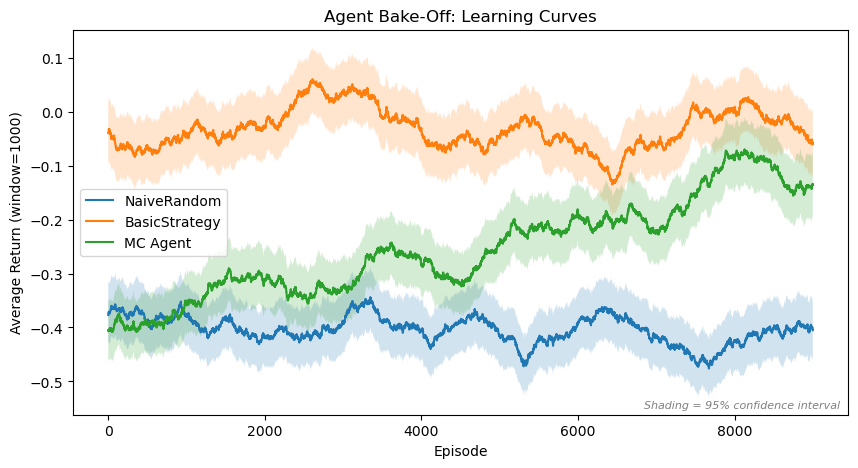

In [25]:
# Bake-off: Learning Curve Overlay
import gymnasium as gym
from blackjack_agent import BlackjackAgent
from naive_agent import NaiveAgent
from basic_strategy import BasicStrategy
from episode_runner import EpisodeRunner
from visualizer import Visualizer

env = gym.make("Blackjack-v1", sab=True)
runner = EpisodeRunner(env)
viz = Visualizer()

num_episodes = 10_000

# Train MC agent
mc_agent = BlackjackAgent(epsilon=1.0,
                          decay_schedule=lambda eps: max(0.01, eps - 1/num_episodes))
mc_rewards = runner.run_training(mc_agent, num_episodes=num_episodes)

# Run baselines
naive_agent = NaiveAgent(strategy="random")
# naive_agent = NaiveAgent(strategy="always_hit")
# naive_agent = NaiveAgent(strategy="always_stick")
naive_rewards = runner.run_training(naive_agent, num_episodes=num_episodes)

basic_agent = BasicStrategy()
basic_rewards = runner.run_training(basic_agent, num_episodes=num_episodes)

# Plot overlay
reward_series = {
    "NaiveRandom": naive_rewards,
    "BasicStrategy": basic_rewards,
    "MC Agent": mc_rewards,
}

fig = viz.plot_bakeoff_curves(reward_series, window_size=1_000)
import matplotlib.pyplot as plt
plt.show()

viz.save_plot(fig, "../img/bakeoff_learning_curves.png")


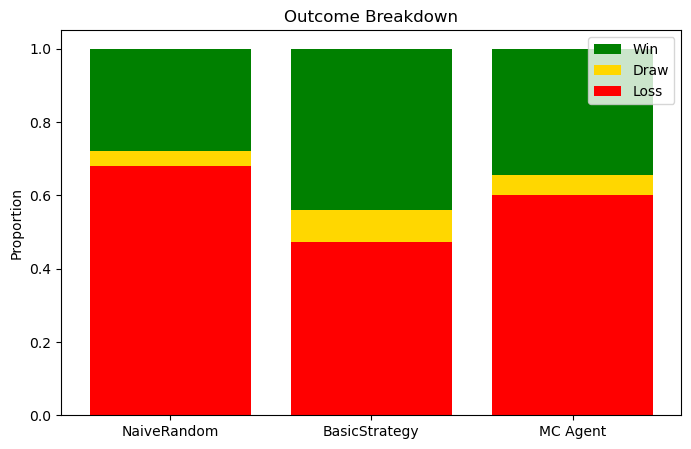

In [26]:
# Bake-off: Outcome Breakdown (stacked bar chart)
fig_outcomes = viz.plot_outcome_breakdown(reward_series)

viz.save_plot(fig_outcomes, "../img/outcome_breakdown.png")


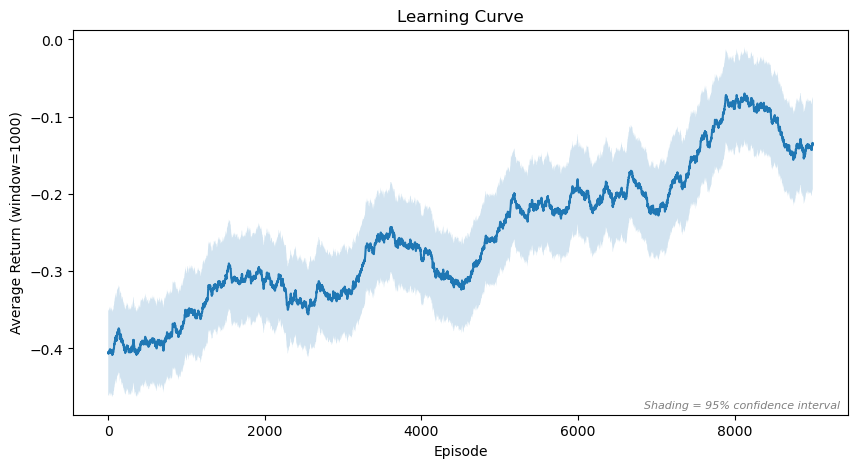

In [27]:
# MC Agent: Learning Curve
fig_lc = viz.plot_learning_curve(mc_rewards, window_size=1000, show_ci=True)

viz.save_plot(fig_lc, "../img/mc_learning_curve.png")


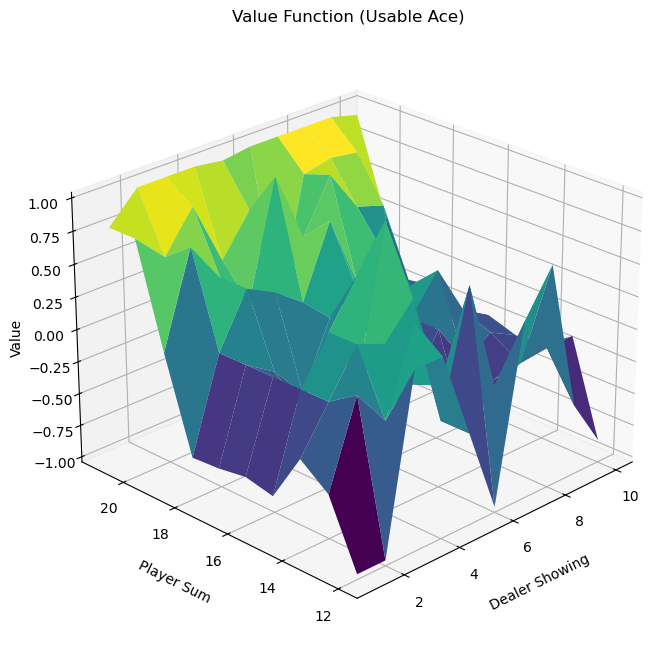

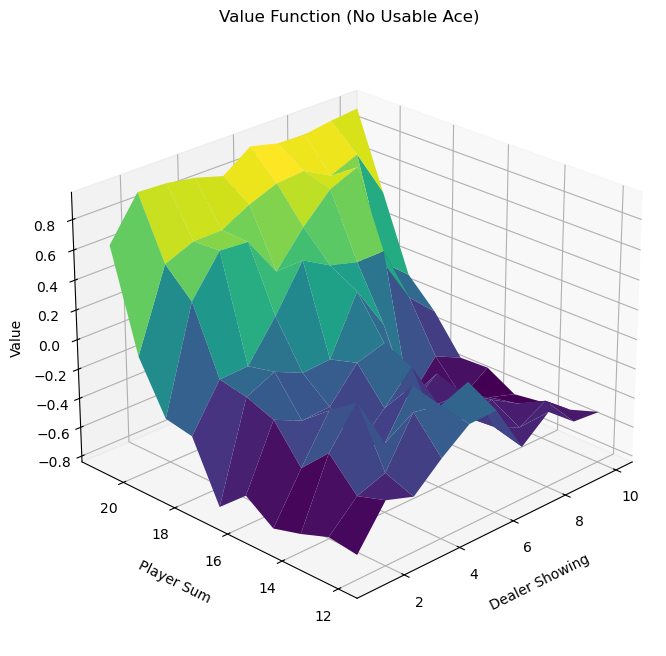

In [28]:
# 3D Value Surface Plots
value_fn = mc_agent.get_value_function()

fig_ace = viz.plot_value_surface(value_fn, "Value Function (Usable Ace)", usable_ace=True)
fig_no_ace = viz.plot_value_surface(value_fn, "Value Function (No Usable Ace)", usable_ace=False)

viz.save_plot(fig_ace, "../img/value_surface_usable_ace.png")
viz.save_plot(fig_no_ace, "../img/value_surface_no_usable_ace.png")


## Epsilon Experimentation

In [29]:
# TODO: Epsilon experimentation
# - Train with different fixed epsilon values (e.g., 0.01, 0.1, 0.3)
# - Train with different decay schedules (e.g., linear, exponential)
# - Compare learning curves across configurations
# - Compare final average returns across configurations

## BlackjackSimulation (CLI Orchestrator)

In [30]:
# TODO: BlackjackSimulation - stub
# - __init__(num_episodes, epsilon, decay_schedule, output_dir)
#   - output_dir defaults to W3/img/
# - run(): wire together Agent, EpisodeRunner, BasicStrategy, Visualizer
#   - Train agent, generate all visualizations, save artifacts to output_dir
# - CLI entry point: parse args and call run()

In [31]:
# TODO: BlackjackSimulation - unit tests
# - Test run() completes without error
# - Test CLI arg parsing produces correct configuration
# - Test output artifacts are created in the specified directory

## Run Acceptance Tests

In [32]:
# TODO: Run acceptance tests
# - Verify bake-off: trained agent outperforms naive baselines and
#   approaches or exceeds BasicStrategy on average returns
# - Verify all visualizations render and save correctly
# - Verify CLI simulation runs end-to-end